## Focal Length Calibration

For each ZL034 and ZR034 we will find a model of the focal length $fl$ as a function of focus motor-count $fmc$. The model would be a simple line, given as 

$$fl(fmc) = \alpha_{fl} + \beta_{fl} \cdot fmc$$

Let $D_{fl-fmc,ZL34}=\left\{(fl_{l,0}, fmc_{l,0}), (fl_{l,1}, fmc_{l,1}), \dots, (fl_{l,n}, fmc_{l,n})\right\}$ be the set of zcam left 34mm focal length and focus motor count pairs and let $D_{fl-fmc,ZR34}=\left\{(fl_{r,0}, fmc_{r,0}), (fl_{r,1}, fmc_{r,1}), \dots, (fl_{r,n}, fmc_{r,n})\right\}$ be the corresponding dataset of the right zcam. 

Need to solve 

$$\min_{\alpha_l, \beta_l} \sum_{i=0}^n ( (\beta_l \cdot fmc_i +  \alpha_l) - fl_i)^2$$
for $\alpha_l, \beta_l$. 

To do so, we utilize the normal equation 

$$\theta_l = (X_l^TX_l)^{-1}X_l^TY_l$$
where 
\begin{align*}
  \theta=\begin{bmatrix}\beta_l\\\alpha_l\end{bmatrix} &&
  X_l = \begin{bmatrix}fmc_{l,0}&&1\\fmc_{l,1}&&1\\ \vdots&&1 \\fmc_{l,n}&&1\end{bmatrix} &&
  Y_l = \begin{bmatrix}fl_{l,0}\\fl_{l,1}\\\vdots\\fl_{l,n}\end{bmatrix}
\end{align*}

where the inverse we use would be the penrose pseudo-inverse. 


Similarly for the right cameras, 
$$\alpha_r, \beta_r = \arg\min_{\alpha_r, \beta_r} \sum_{i=0}^n ( (\beta_r \cdot fmc_i +  \alpha_r) - fl_i)^2$$

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data = pd.read_excel(data_fpath)

zl34 = data[data["cam"] == "ZL034"].copy()
zr34 = data[data["cam"] == "ZR034"].copy()

print(f"Number of data points for zl034:{zl34.shape[0]}")
print(f"Number of data points for zr034:{zr34.shape[0]}")

Number of data points for zl034:344
Number of data points for zr034:323


X_l shape:(344, 2); Y_l shape:(344,); theta_l:[5.01639695e-02 4.68209789e+03]; MSE_l:101.042097
X_r shape:(323, 2); Y_r shape:(323,); theta_r:[5.31455367e-02 4.68747381e+03]; MSE_r:143.618222


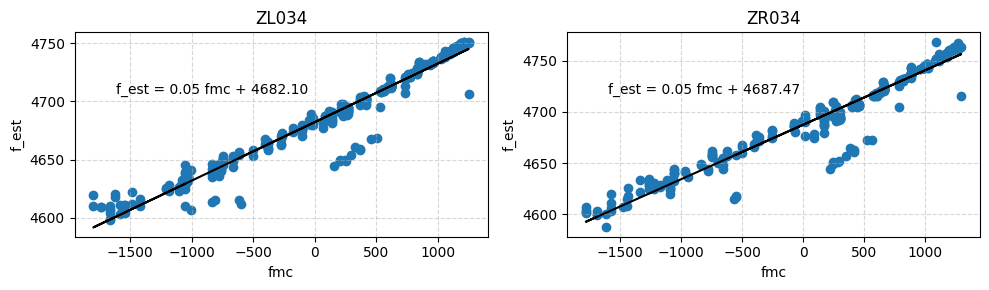

In [28]:
## solve for an approx BFL to identfy outliers

# solve for theta_left
X_l = np.vstack([zl34["fmc"], np.ones(zl34.shape[0])]).T
Y_l = zl34["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
residual_l = ((Y_l - X_l @ theta_l).T @ (Y_l - X_l @ theta_l))/X_l.shape[0]

print(f"X_l shape:{X_l.shape}; Y_l shape:{Y_l.shape}; theta_l:{theta_l}; MSE_l:{residual_l:0.6f}")

# solve for theta_right
X_r = np.vstack([zr34["fmc"], np.ones(zr34.shape[0])]).T
Y_r = zr34["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
residual_r = ((Y_r - X_r @ theta_r).T @ (Y_r - X_r @ theta_r))/X_r.shape[0]

print(f"X_r shape:{X_r.shape}; Y_r shape:{Y_r.shape}; theta_r:{theta_r}; MSE_r:{residual_r:0.6f}")

# plot Y_l as a funciton of X_l with the line of best fit
fig, ax = plt.subplots(1, 2, figsize=(10,3))

# left focal-length as a function of fmc
ax[0].scatter(zl34["fmc"], zl34["f_est"], label="f_est")
ax[0].plot(zl34["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)
ax[0].text(0.1, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)


# right focal-length as a function of fmc
ax[1].scatter(zr34["fmc"], zr34["f_est"], label="f_est")
ax[1].plot(zr34["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)
ax[1].text(0.1, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)


plt.tight_layout()
plt.show()

## $q^m_c$ fit

Here we model the quaternion representation of the rotation from the $m$ frame to the $c$ frame as a spherical linear interpolation

$$q^m_{c,z}(focus) = q^m_{c,z,0} \otimes (q^m_{c,z,1})^{\frac{focus}{1000}}$$

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

In [62]:
# outliers = []

# focal length outliers
# fl_outlier_fpath = "./focal_length_outliers.txt"
# with open(fl_outlier_fpath,'r') as f:
#   outliers += [l.strip() for l in f.readlines()]

# # geocal outliers
# gc_outlier_fpath = "./geocal_outliers.txt"
# with open(gc_outlier_fpath,'r') as f:
#   outliers += [l.strip() for l in f.readlines()]

data_fpath = "data/m41_site_cal_v229_v1_Z034_filtered.xlsx"
data = pd.read_excel(data_fpath)
print(f"Num data points: {len(data)}")

# Remove outliers
# data = data[~data['name'].isin(outliers)]
# print(f"Num data points after removing outliers: {len(data)}")

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["h_r_vec" ] = [to_vec_space(v) for v in data["h_r_est"]]
data["v_r_vec" ] = [to_vec_space(v) for v in data["v_r_est"]]
data["a_r_vec" ] = [to_vec_space(v) for v in data["a_r_est"]]
data["c_r_vec" ] = [to_vec_space(v) for v in data["c_r_est"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]
data["t_rpm_vec" ] = [to_vec_comma(v) for v in data["t_rpm"]]

zl34 = data[data["cam"] == "ZL034"].copy()
zl34.reset_index(drop=True, inplace=True)
zr34 = data[data["cam"] == "ZR034"].copy()
zr34.reset_index(drop=True, inplace=True)

print(f"Number of data points zl034 (all fmc):{zl34.shape[0]}")
print(f"Number of data points zr034 (all fmc):{zr34.shape[0]}")


Num data points: 640
Number of data points zl034 (all fmc):328
Number of data points zr034 (all fmc):312


In [52]:
left_fl = {"alpha": 4.68846664e+03, "beta": 4.96979943e-02}
right_fl = {"alpha": 4.69545322e+03, "beta": 5.07842345e-02}


def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

def get_q_rc_data(idx:int, data_: np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from data
  """
  H_r = get_H_r_data(idx, data_)
  H_c = get_KC(idx, data_).T
  return R.from_matrix(H_r @ np.linalg.inv(H_c)).as_quat()

def get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3, 
                  idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc_0 = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]))
  rot_mc_1 = R.from_quat(np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]))
  f = data_["fmc"][idx]
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True)

In [55]:
# cumulative data for ZL034 and ZR034
data034 = pd.concat([zl34, zr34], axis=0)
data034.reset_index(drop=True, inplace=True)


def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data034.shape[0]):
    q_rc_data = get_q_rc_data(i, data034)
    if data034["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
    
    elif data034["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data034)
      total_dist += dist_q(q_rc_data, q_rc_model)
      count += 1
  
  return total_dist/count

x0 = [  0.00035132, -0.0004781 ,  0.00048555, -0.99999971,
      0.5, 0.5, 0.5, 0.5,
      0.5, 0.5, 0.5, 0.5,
      0.5, 0.5, 0.5, 0.5,
      0.5, 0.5, 0.5, 0.5]
res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":200})

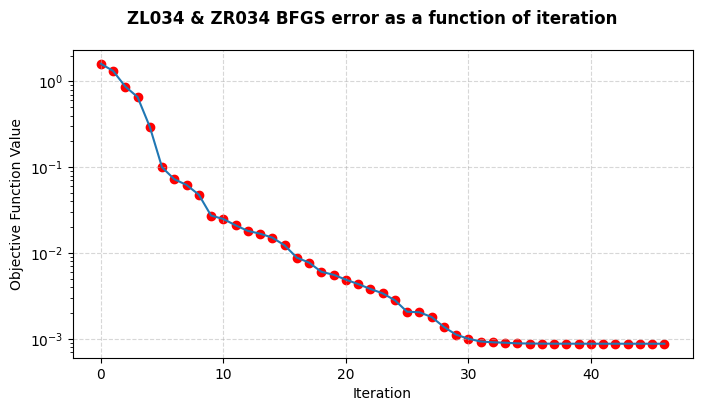

In [56]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

In [57]:
q_rrp = np.array(res.x[:4])/np.linalg.norm(np.array(res.x[:4]))
q_cm_zl_0 = np.array(res.x[4:8])/np.linalg.norm(np.array(res.x[4:8]))
q_cm_zl_1 = np.array(res.x[8:12])/np.linalg.norm(np.array(res.x[8:12]))
q_cm_zr_0 = np.array(res.x[12:16])/np.linalg.norm(np.array(res.x[12:16]))
q_cm_zr_1 = np.array(res.x[16:20])/np.linalg.norm(np.array(res.x[16:20]))
print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_0:{q_cm_zl_0}")
print(f"q_cm_zl_1:{q_cm_zl_1}")
print(f"q_cm_zr_0:{q_cm_zr_0}")
print(f"q_cm_zr_1:{q_cm_zr_1}")

# rotation difference for ZL
rot_zl_0 = R.from_quat(q_cm_zl_0)
rot_zl_1 = R.from_quat(q_cm_zl_1)
c_zl = (rot_zl_0.inv() * rot_zl_1).as_euler('xyz', degrees=1)
print(f"ZL max-min rotation deviation:{c_zl}, norm:{np.linalg.norm(c_zl)}")

# rotation difference for ZR
rot_zr_0 = R.from_quat(q_cm_zr_0)
rot_zr_1 = R.from_quat(q_cm_zr_1)
c_zr = (rot_zr_0.inv() * rot_zr_1).as_euler('xyz', degrees=1)
print(f"ZL max-min rotation deviation:{c_zr}, norm:{np.linalg.norm(c_zr)}")


## fitted 070224 with outliers
# q_rrp = [ 1.85490780e-04, 3.88063323e-06, -4.64154547e-04, -9.99999875e-01]
# q_cm_zl_0 = [0.49044722, 0.50414185, 0.50711849, 0.49812986]
# q_cm_zl_1 = [0.49066946, 0.50454512, 0.50651278, 0.49811897]
# q_cm_zr_0 = [0.50358695, 0.48953263, 0.49939595, 0.50730826]
# q_cm_zr_1 = [0.50359789, 0.48997727, 0.49892472, 0.50733181]

## fitted with fmin=-5000, fmax=5000
# q_rrp = [ 5.52654526e-05, 3.51992116e-04, -8.47484634e-04, -9.99999577e-01]
# q_cm_zl_0 = [0.49042533, 0.50426876, 0.5076071, 0.49752491]
# q_cm_zl_1 = [0.4906972, 0.5047649, 0.50594822, 0.49844263]
# q_cm_zr_0 = [0.50402815, 0.48924132, 0.49938815, 0.50715879]
# q_cm_zr_1 = [0.50357405, 0.49005808, 0.49845026, 0.50774364]

## fitted with fmin=-1000, fmax=1000
# q_rrp:[ 5.51635532e-05  3.52219198e-04 -8.44765441e-04 -9.99999580e-01]
# q_cm_zl_0:[0.4905358  0.50446401 0.50694918 0.49788876]
# q_cm_zl_1:[0.49058555 0.50456867 0.50661331 0.49807552]
# q_cm_zr_0:[0.50384627 0.48956806 0.499016   0.50739046]
# q_cm_zr_1:[0.50375291 0.489734   0.49882751 0.50750836]

## fitter 070324 fmin=-1000, fmax=1000
# q_rrp = [ 7.51295042e-05  3.51915147e-04 -8.39536219e-04 -9.99999583e-01]
# q_cm_zl_0 [0.49055518 0.50451193 0.50691071 0.49786029]
# q_cm_zl_1:[0.49058697 0.50456107 0.5065959  0.49809953]
# q_cm_zr_0:[0.50384936 0.48958132 0.49901671 0.5073739 ]
# q_cm_zr_1:[0.5037479  0.48973411 0.49883256 0.50750825]

## fitter 070324 linear in exponant
# q_rrp:[ 7.45645440e-05  3.51676710e-04 -8.44843512e-04 -9.99999579e-01]
# q_cm_zl_0:[0.49057316 0.50453528 0.50674909 0.49798343]
# q_cm_zl_1:[ 4.02486085e-05 -1.33691695e-04 -1.41653222e-04  9.99999980e-01]
# q_cm_zr_0:[0.50380067 0.48965644 0.49892107 0.50744381]
# q_cm_zr_1:[ 2.33921698e-05 -1.38814667e-05 -1.44154281e-04  9.99999989e-01]



Final function:0.000878
Final Jacobian:0.000558
q_rrp:[ 5.51277082e-05  3.46611661e-04 -7.85697625e-04 -9.99999630e-01]
q_cm_zl_0:[0.49055634 0.504521   0.50681733 0.49794501]
q_cm_zl_1:[ 7.91548065e-05 -1.18646514e-04 -1.80799581e-04  9.99999973e-01]
q_cm_zr_0:[0.50379237 0.48965398 0.49896909 0.5074072 ]
q_cm_zr_1:[ 3.14480239e-05 -1.09409422e-05 -1.79232289e-04  9.99999983e-01]
ZL max-min rotation deviation:[  67.99450667  -88.56472996 -157.69389899], norm:193.22093599975506
ZL max-min rotation deviation:[-60.00643487 -88.52773985 -30.31670961], norm:111.16220504605299


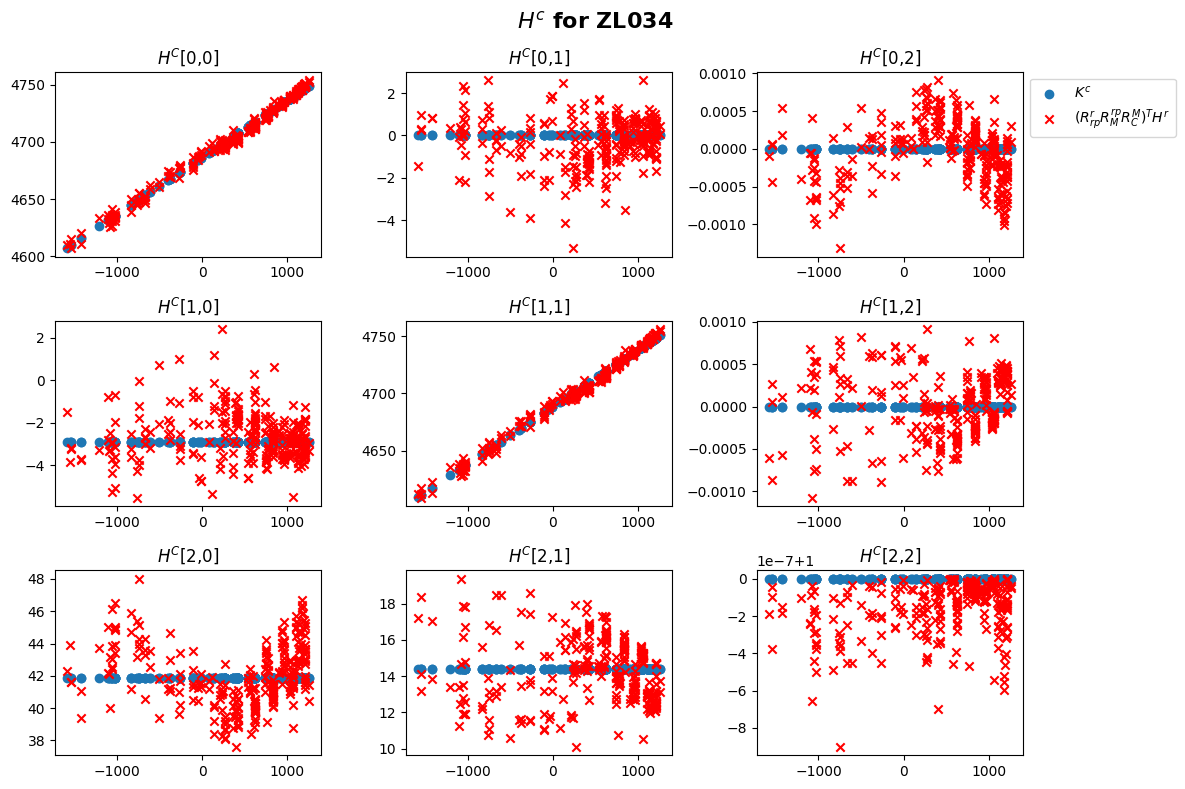

In [35]:
# Compute H_c for ZL034
H_c_model_zl = []
H_c_gt_zl = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zl34.shape[0]):
  # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zl34))
  
  # slerp between q_cm_zl_a and q_cm_zl_b
  f = zl34["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zl_0)
  rot_mc_1 = R.from_quat(q_cm_zl_1)
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zl34)
  H_c_model_zl.append(np.linalg.inv(R_rc) @ H_r)

  H_c_gt_zl.append(get_KC(i, zl34).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl34["fmc"], [H[r,c] for H in H_c_gt_zl], label="expectation")
    ax[r,c].scatter(zl34["fmc"], [H[r, c] for H in H_c_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

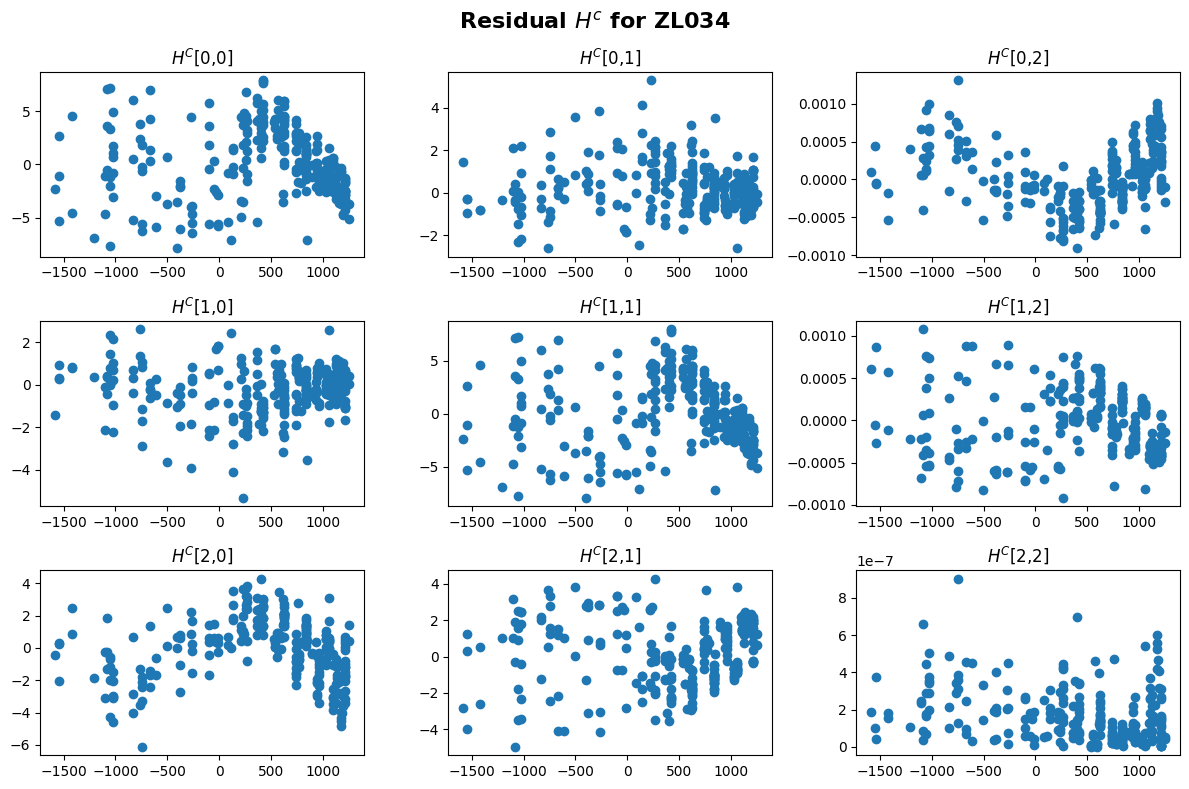

In [36]:
# plot the residual between H_c_model_zl and H_c_gt_zl

residual_Hc_zl = np.array(H_c_gt_zl) - np.array(H_c_model_zl)
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl34["fmc"], [H[r,c] for H in residual_Hc_zl], label="residual")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

fig.suptitle("Residual $H^c$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

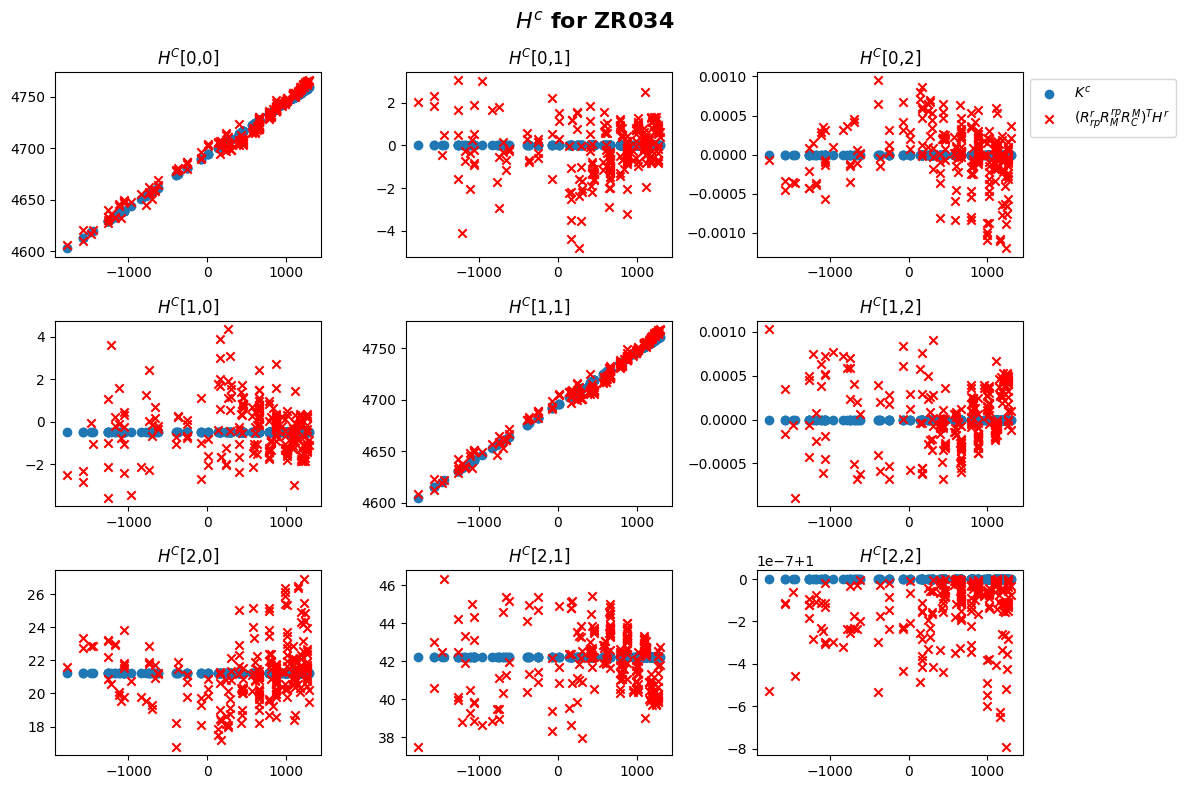

In [37]:
# Compute H_c for ZL034
H_c_model_zr = []
H_c_gt_zr = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zr34.shape[0]):
  # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zr34))
  
  # slerp between q_cm_zl_a and q_cm_zl_b
  f = zr34["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zr_0)
  rot_mc_1 = R.from_quat(q_cm_zr_1)
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()

  # tranform to camera frame
  H_r = get_H_r_data(i, zr34)
  H_c_model_zr.append(np.linalg.inv(R_rc) @ H_r)

  H_c_gt_zr.append(get_KC(i, zr34).T)


fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr34["fmc"], [H[r,c] for H in H_c_gt_zr], label="expectation")
    ax[r,c].scatter(zr34["fmc"], [H[r, c] for H in H_c_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

ax[0,2].legend(["$K^c$", "$(R^r_{rp} R^{rp}_M R^M_C)^T H^r$"], bbox_to_anchor=(1.6,1))


fig.suptitle("$H^c$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

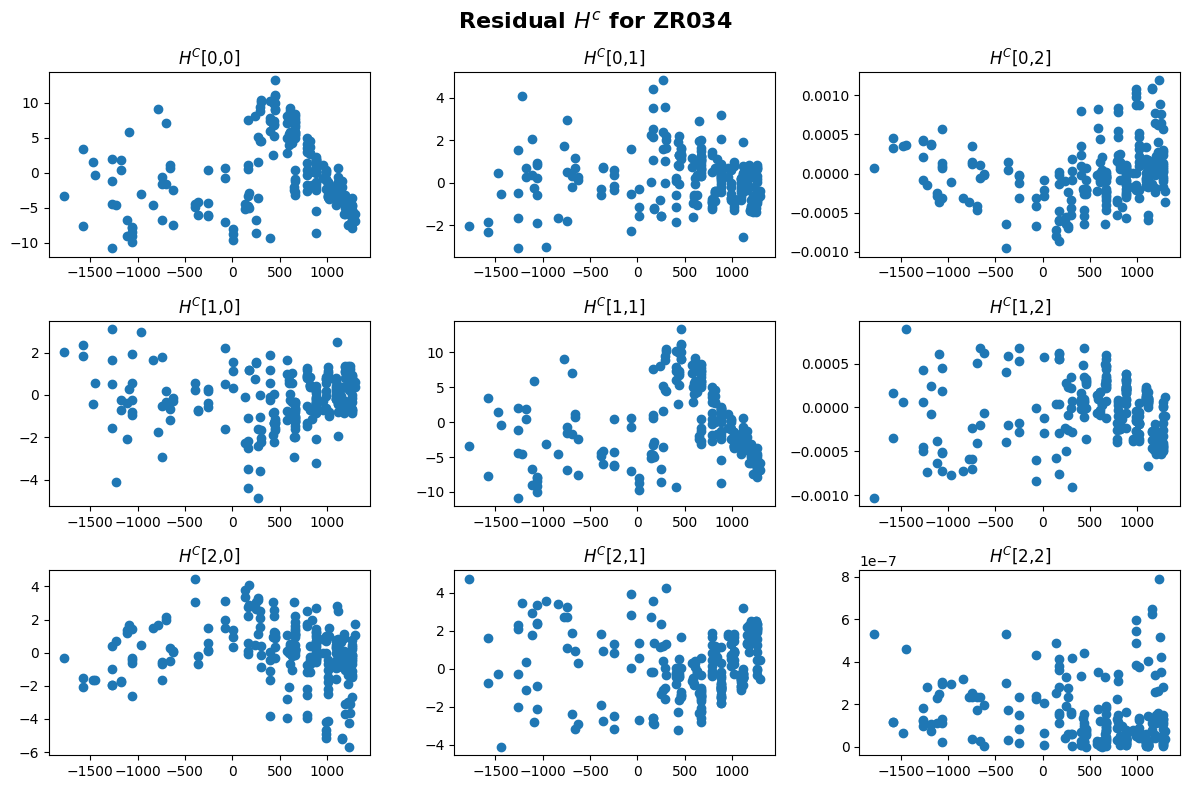

In [38]:
residual_Hr_zr = np.array(H_c_gt_zr) - np.array(H_c_model_zr)
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr34["fmc"], [H[r,c] for H in residual_Hr_zr], label="residual")
    ax[r,c].set_title(f"$H^C$[{r},{c}]")

fig.suptitle("Residual $H^c$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

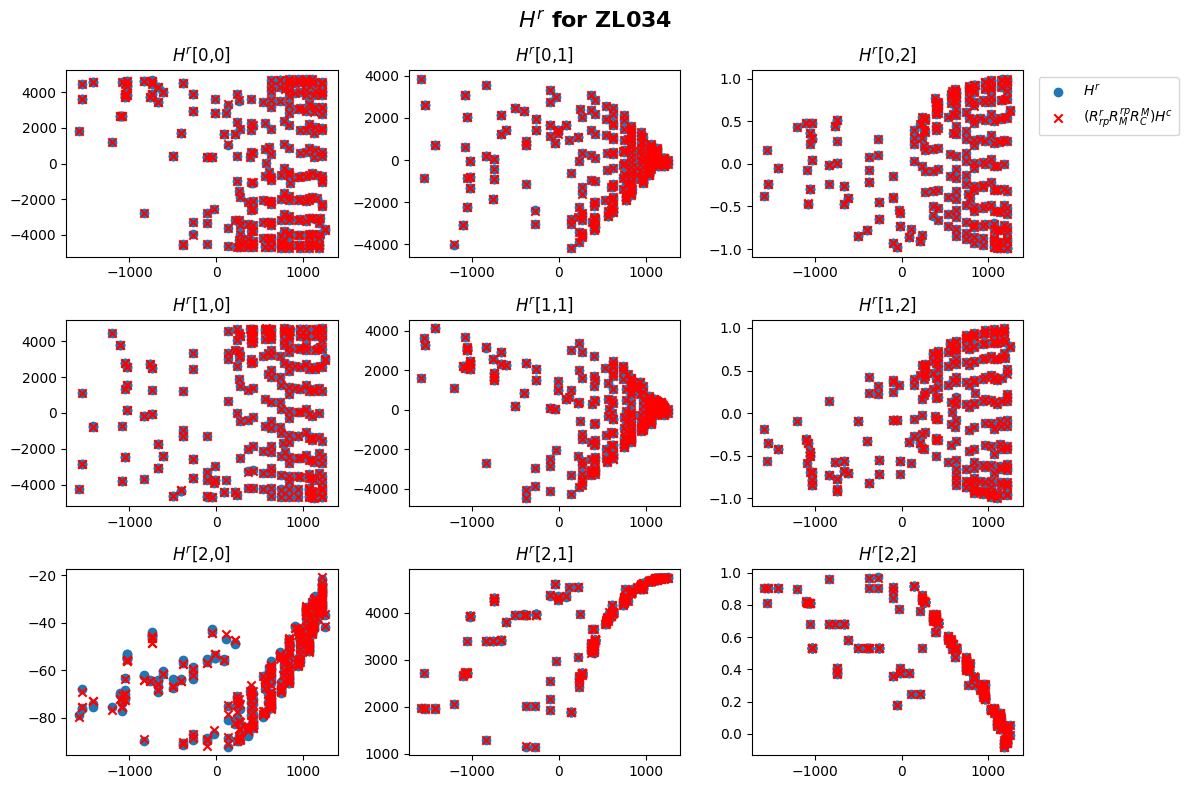

In [39]:
# plot H_r matrix as a function of f
H_r_data_zl = []
H_r_model_zl = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zl34.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zl34))
  
  # slerp between q_cm_zl_a and q_cm_zl_b
  f = zl34["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zl_0)
  rot_mc_1 = R.from_quat(q_cm_zl_1)
  # rot_mc = rot_mc_0 * ((rot_mc_0.inv() * rot_mc_1)**((f-left_f_min)/(left_f_max-left_f_min)))
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  H_c = get_KC(i, zl34).T
  H_r_model_zl.append(R_rc @ H_c)

  # data
  H_r_data_zl.append(get_H_r_data(i, zl34))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl34["fmc"], [H[r,c] for H in H_r_data_zl], label="expectation")
    ax[r,c].scatter(zl34["fmc"], [H[r, c] for H in H_r_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle("$H^r$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

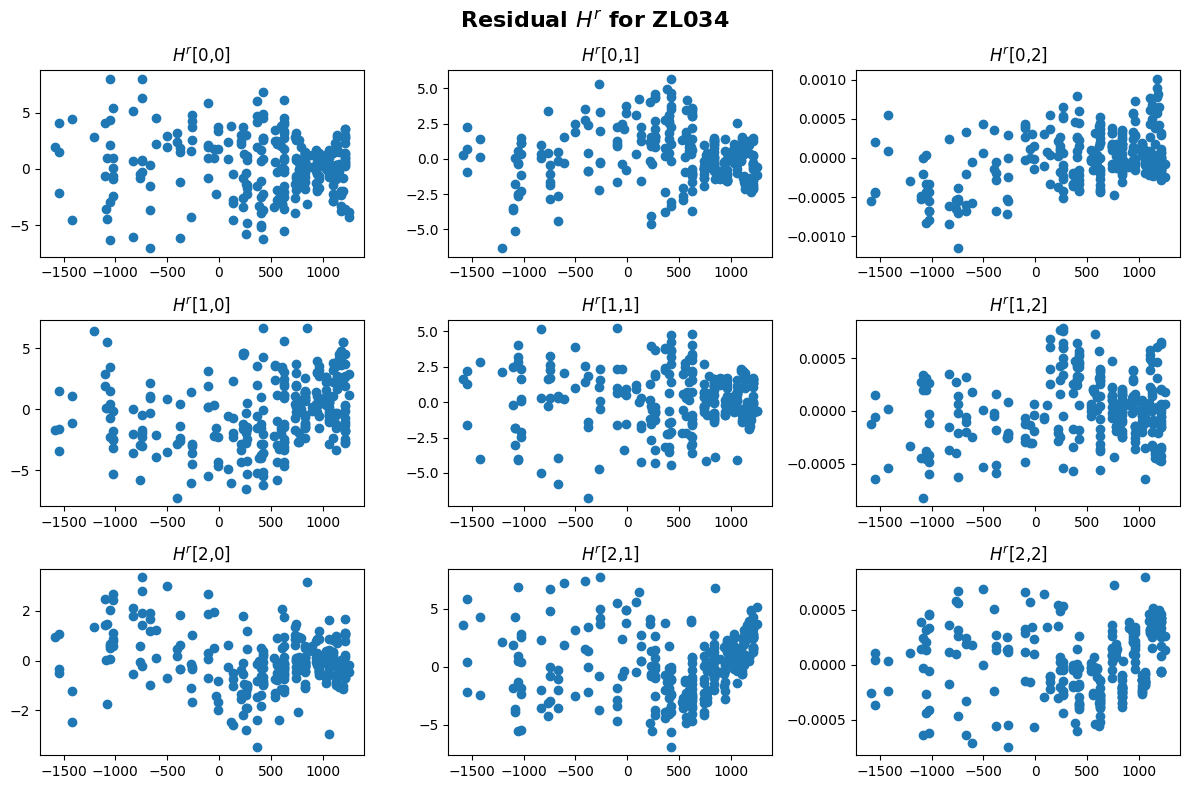

In [40]:
residual_Hr_zl = np.array(H_r_data_zl) - np.array(H_r_model_zl)
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl34["fmc"], [H[r,c] for H in residual_Hr_zl], label="residual")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

fig.suptitle("Residual $H^r$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

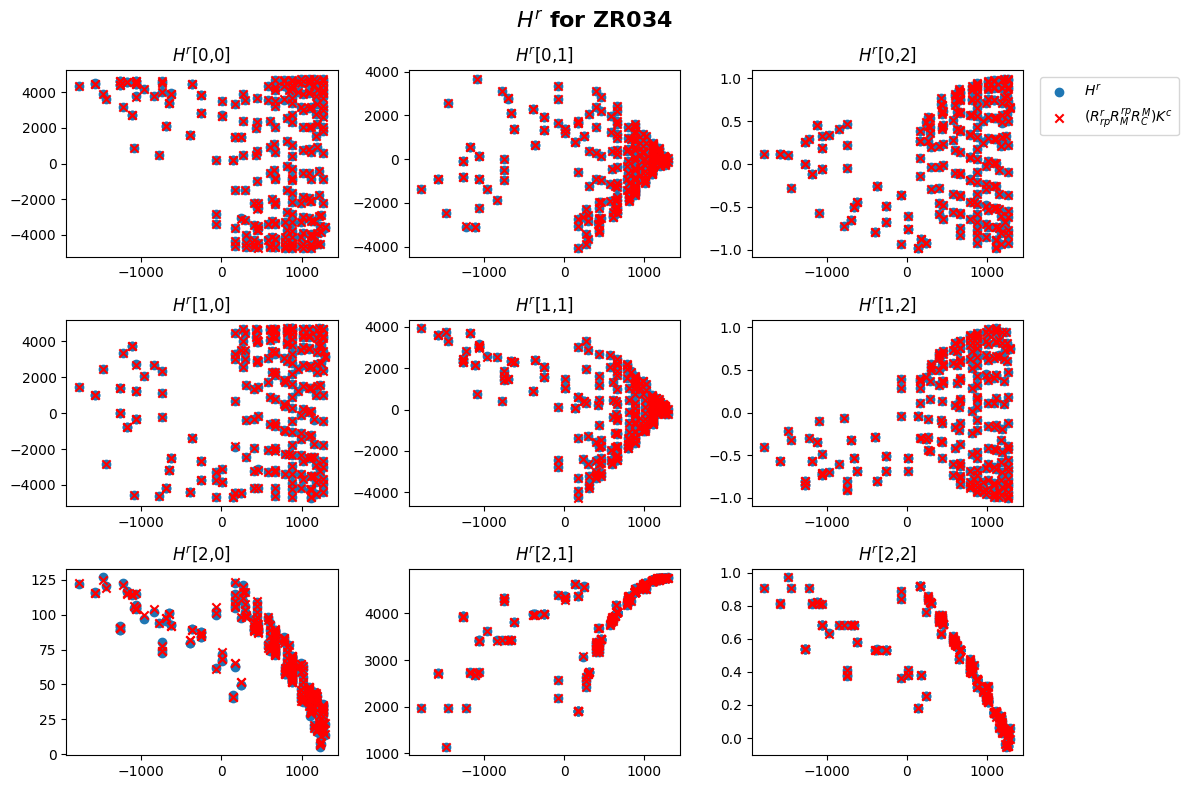

In [41]:
# plot H_r matrix as a function of f
H_r_data_zr = []
H_r_model_zr = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zr34.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zr34))
  
  # slerp between q_cm_zr_a and q_cm_zr_b
  f = zr34["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zr_0)
  rot_mc_1 = R.from_quat(q_cm_zr_1)
  # rot_mc = rot_mc_0 * ((rot_mc_0.inv() * rot_mc_1)**((f-right_f_min)/(right_f_max-right_f_min)))
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  H_c = get_KC(i, zr34).T
  H_r_model_zr.append(R_rc @ H_c)

  # data
  H_r_data_zr.append(get_H_r_data(i, zr34))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr34["fmc"], [H[r,c] for H in H_r_data_zr], label="expectation")
    ax[r,c].scatter(zr34["fmc"], [H[r, c] for H in H_r_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) K^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle("$H^r$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

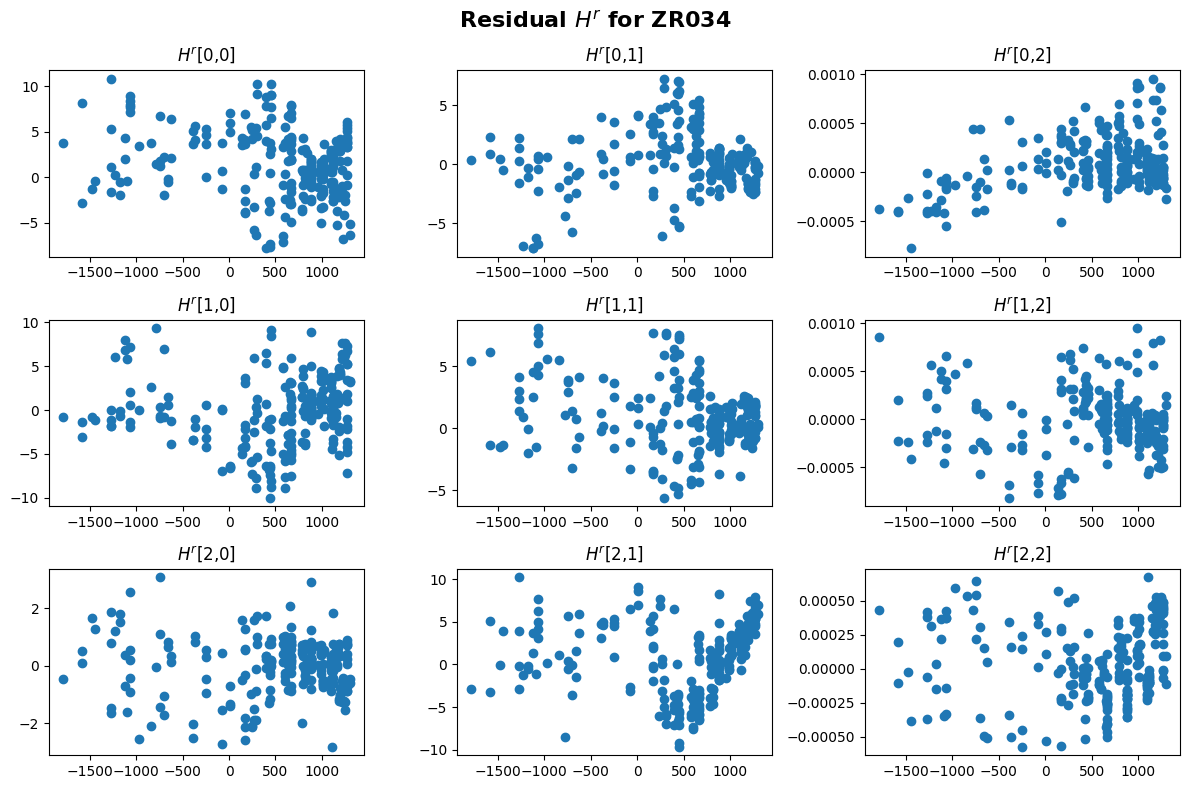

In [42]:
residual_Hr_zr = np.array(H_r_data_zr) - np.array(H_r_model_zr)
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr34["fmc"], [H[r,c] for H in residual_Hr_zr], label="residual")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

fig.suptitle("Residual $H^r$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

## Fitting Translations $t^r_{r'}$, $t^m_c$

The relationship between the $c^r$ and $c^c$ can be derived by considering last column of the transformation of $\mathcal{H}^c$ to $\mathcal{H}^r$. 
\begin{align*}
    \begin{bmatrix}c^r\\1\end{bmatrix} &= T^r_{r'} T^{r'}_m T^m_{c} \begin{bmatrix}c^c\\1\end{bmatrix}\\
    c^r &= R^r_{r'} R^{r'}_m R^m_c c^c + R^r_{r'}R^{r'}_m t^m_c + R^r_{r'}t_m^{r'}+t^r_{r'}
\end{align*}
But since $c^c = \begin{bmatrix}0&0&0\end{bmatrix}^T$, so the above reduces to 
\begin{align*} c^r &=  R^r_{r'}R^{r'}_m t^m_c + R^r_{r'}t_m^{r'}+t^r_{r'}
\end{align*}
For each left and right camera model the translation from the mast frame $m$ to the camera frame $c$ as a linear function of $focus$
\begin{align*}
    t^m_{c,left}(focus) &= t^m_{c,left,0} + t^m_{c,left,1} * focus\\
    t^m_{c,right}(focus) &= t^m_{c,right,0} + t^m_{c,right,1} * focus
\end{align*}


Thus, in total we will need to solve for $t^r_{r'}$, $t^m_{c,left,0}$, $t^m_{c,left,1}$, $t^m_{c,right,0}$ and $t^m_{c,right,1}$ such that squared euclidean distance between the $c$ vector in the rover's reference frame is minimize, 
\begin{align*}
    \min_{t^r_{r'}, t^m_{c,left,0}, t^m_{c,left,1}, t^m_{c,right,0}, t^m_{c,right,1}} \sum_{i}\| c_i^r - (R^r_{r'}R^{r'}_{m,i} t^m_{c,i} + R^r_{r'}t_{m,i}^{r'}+t^r_{r'}) \|^2
\end{align*}


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

In [63]:
q_rrp = [ 7.45645440e-05, 3.51676710e-04, -8.44843512e-04, -9.99999579e-01]
q_cm_zl_0 = [0.49057316, 0.50453528, 0.50674909, 0.49798343]
q_cm_zl_1 = [ 4.02486085e-05, -1.33691695e-04, -1.41653222e-04, 9.99999980e-01] 
q_cm_zr_0 = [0.50380067, 0.48965644, 0.49892107, 0.50744381] 
q_cm_zr_1 = [ 2.33921698e-05, -1.38814667e-05, -1.44154281e-04, 9.99999989e-01]

def get_c_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  c_i = np.expand_dims(data_["c_r_vec"][idx], axis=1)
  return c_i

def get_R_rrp()->np.ndarray:
  """
  Rotation matrix going from r to r_prime frame
  """
  return R.from_quat(q_rrp).as_matrix()

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_R_mc(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from mast frame to camera frame
  """
  f = data_["fmc"][idx]
  
  q_cm_0 = q_cm_zl_0 if data_["cam"][idx] == "ZL034" else q_cm_zr_0
  q_cm_1 = q_cm_zl_1 if data_["cam"][idx] == "ZR034" else q_cm_zr_1

  rot_mc_0 = R.from_quat(q_cm_0)
  rot_mc_1 = R.from_quat(q_cm_1)

  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  return rot_mc.as_matrix()

def get_t_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Translation vector going from r_prime to mast frame
  """
  return np.expand_dims(data_["t_rpm_vec"][idx], axis=1)

In [64]:
data34 = pd.concat([zl34, zr34], axis=0).reset_index(drop=True)

def dist_metric(c_r_data, c_r_model):
  return np.linalg.norm(c_r_data - c_r_model, ord=2)**2

def obj(x):
  obj_val = 0
  count = 0
  t_rrp = np.expand_dims(x[:3], axis=1)
  R_rrp = get_R_rrp()
  t_mc_zl_0 = np.expand_dims(x[3:6], axis=1)
  t_mc_zl_1 = np.expand_dims(x[6:9], axis=1)
  t_mc_zr_0 = np.expand_dims(x[9:12], axis=1)
  t_mc_zr_1 = np.expand_dims(x[12:], axis=1)

  for i in range(data34.shape[0]):  
    # compute the data
    c_r_data = get_c_r_data(i, data34)

    # compute the model
    f = data34["fmc"][i]
    R_rpm = get_R_rpm(i, data34)
    t_mc = t_mc_zl_0 + f * t_mc_zl_1 if data34["cam"][i]=="ZL034" else t_mc_zr_0 + f * t_mc_zr_1
    t_rpm = get_t_rpm(i, data34)
    
    

    c_r_model = R_rrp @ R_rpm @ t_mc + R_rrp @ t_rpm + t_rrp
    # c_r_model = np.expand_dims(c_r_model, axis=1)

    obj_val += dist_metric(c_r_data, c_r_model)
    count += 1
  
  return obj_val / count

# [t_rrp0, t_rrp1, t_rrp2, 
#  t_mc_zl_a0, t_mc_zl_a1, t_mc_zl_a2,
#  t_mc_zl_b0, t_mc_zl_b1, t_mc_zl_b2,
#  t_mc_zr_a0, t_mc_zr_a1, t_mc_zr_a2,
#  t_mc_zr_b0, t_mc_zr_b1, t_mc_zr_b2 ]
x0 = [0,0,0,
      0.03, 0.124, 0.07, 0, 0, 0,
      0.036, 0.119, 0.067, 0, 0, 0]

res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20})

In [66]:
t_rrp = np.expand_dims(res.x[:3],axis=1)
t_mc_zl_0 = np.expand_dims(res.x[3:6], axis=1)
t_mc_zl_1 = np.expand_dims(res.x[6:9], axis=1)
t_mc_zr_0 = np.expand_dims(res.x[9:12], axis=1)
t_mc_zr_1 = np.expand_dims(res.x[12:], axis=1)


print(f"t_rrp: {res.x[:3]}")
print(f"t_mc_zl_0: {res.x[3:6]}")
print(f"t_mc_zl_1: {res.x[6:9]}")
print(f"t_mc_zr_0: {res.x[9:12]}")
print(f"t_mc_zr_1: {res.x[12:]}")

t_rrp: [ 0.00036446 -0.0008929  -0.00160452]
t_mc_zl_0: [ 0.03433431 -0.12438799 -0.06454942]
t_mc_zl_1: [-2.01312767e-07  4.36809711e-07  5.61620050e-07]
t_mc_zr_0: [ 0.03761013  0.11932903 -0.06415021]
t_mc_zr_1: [1.79296928e-06 5.83527252e-07 5.15827164e-07]


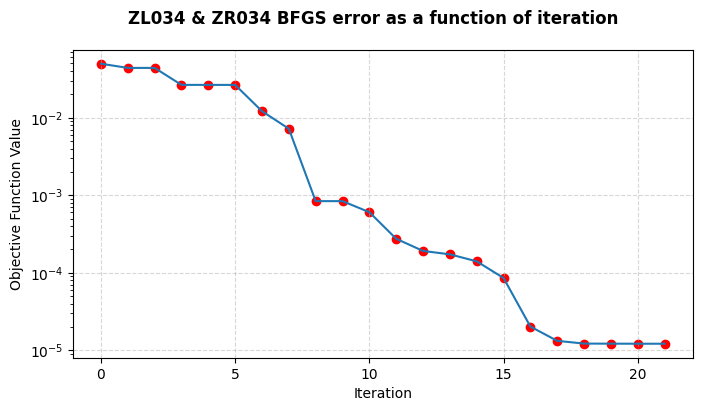

In [67]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

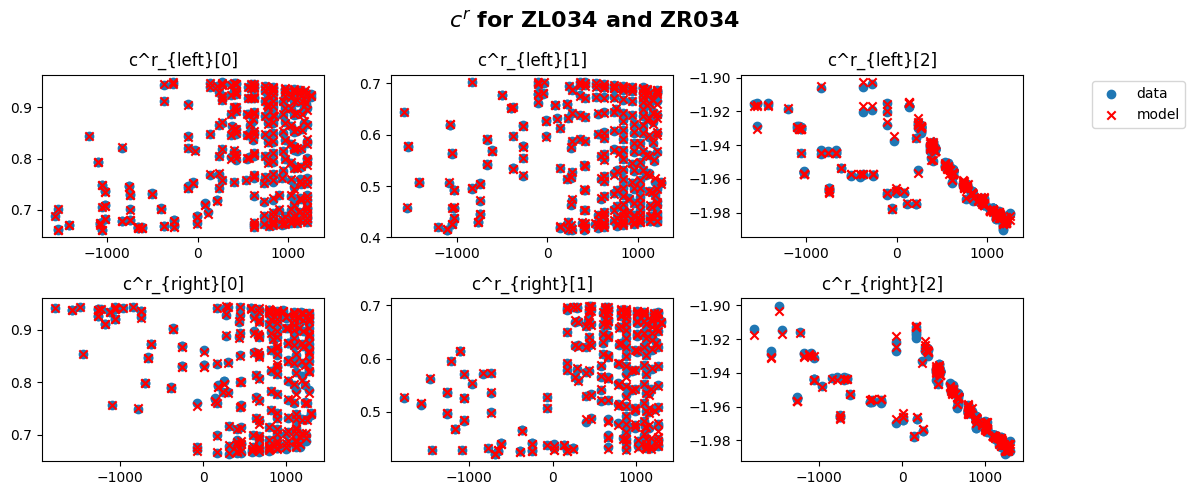

In [ ]:
# plot model c_r vs data c_r
R_rrp = get_R_rrp()
c_r_data_left = []
c_r_model_left = []
for idx in range(zl34.shape[0]):
  f = zl34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zl34)
  t_rpm = get_t_rpm(idx, zl34)
  c_r_data_left.append(get_c_r_data(idx, zl34))
  c_r_model_left.append(R_rrp @ R_rpm @ (t_mc_zl_0 + t_mc_zl_1*f) + R_rrp @ t_rpm + t_rrp)

c_r_data_right = []
c_r_model_right = []
for idx in range(zr34.shape[0]):
  f = zr34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zr34)
  t_rpm = get_t_rpm(idx, zr34)
  c_r_data_right.append(get_c_r_data(idx, zr34))
  c_r_model_right.append(R_rrp @ R_rpm @ (t_mc_zr_0 + t_mc_zr_1*f) + R_rrp @ t_rpm + t_rrp)


# plot c_r data vs c_r model
fig, ax = plt.subplots(2, 3, figsize=(12,5))

for i in range(3):
  ax[0][i].scatter(zl34["fmc"], [c[i] for c in c_r_data_left], label="data")
  ax[0][i].scatter(zl34["fmc"], [c[i] for c in c_r_model_left], label="model", marker="x", color="red")
  ax[0][i].set_title("c^r_{left}"+f"[{i}]")
for i in range(3):
  ax[1][i].scatter(zr34["fmc"], [c[i] for c in c_r_data_right], label="data")
  ax[1][i].scatter(zr34["fmc"], [c[i] for c in c_r_model_right], label="model", marker="x", color="red")
  ax[1][i].set_title("c^r_{right}"+f"[{i}]")


ax[0][2].legend(["data", "model"], bbox_to_anchor=(1.6,1))
fig.suptitle("$c^r$ for ZL034 and ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

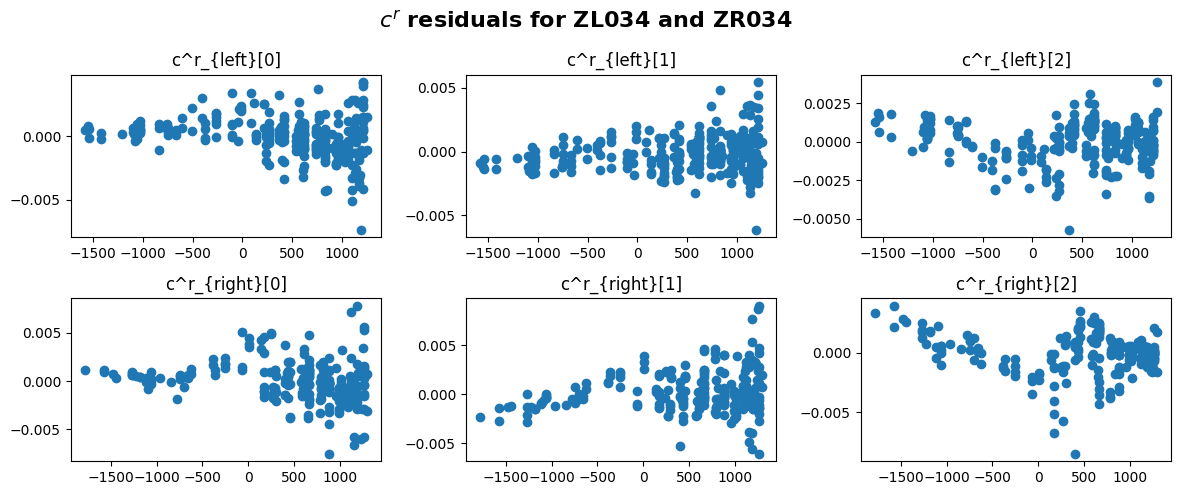

In [ ]:
# plot model c_r vs data c_r
R_rrp = get_R_rrp()
c_r_residual_left = []
for idx in range(zl34.shape[0]):
  f = zl34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zl34)
  t_rpm = get_t_rpm(idx, zl34)
  c_r_residual_left.append(get_c_r_data(idx, zl34) - (R_rrp @ R_rpm @ (t_mc_zl_0 + t_mc_zl_1*f) + R_rrp @ t_rpm + t_rrp))

c_r_residual_right = []
for idx in range(zr34.shape[0]):
  f = zr34["fmc"][idx]
  R_rpm = get_R_rpm(idx, zr34)
  t_rpm = get_t_rpm(idx, zr34)
  c_r_residual_right.append(get_c_r_data(idx, zr34) - (R_rrp @ R_rpm @ (t_mc_zr_0 + t_mc_zr_1*f) + R_rrp @ t_rpm + t_rrp))

# plot c_r data vs c_r model
fig, ax = plt.subplots(2, 3, figsize=(12,5))

for i in range(3):
  ax[0][i].scatter(zl34["fmc"], [c_res[i] for c_res in c_r_residual_left], label="data")
  ax[0][i].set_title("c^r_{left}"+f"[{i}]")
for i in range(3):
  ax[1][i].scatter(zr34["fmc"], [c_res[i] for c_res in c_r_residual_right], label="data")
  ax[1][i].set_title("c^r_{right}"+f"[{i}]")


fig.suptitle("$c^r$ residuals for ZL034 and ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()